# System ID test in Phase 1 of Robot X: Jumping Model


This notebook contains Phase 1 of the jumping model described in the paper titled: Robot X: A Centimeter-Scale Rolling and Jumping Robot for Search and Rescue following Section III. While the main notebook goes through each phase, this only tests Phase 1 with a different tail length and CG location to demonstrate the sensitivity of the model to system identification.

The sections are:
1. Setup
2. Experimental data analysis
3. Phase 1: Contact point and orientation after tail release

# Setup

### Imports and global settings

In [1]:
import numpy as np
import pandas as pd
import csv
import math

from ipywidgets import interact, IntSlider, Layout
from IPython.display import display

from scipy.optimize import brentq
from scipy.integrate import solve_bvp, solve_ivp

import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from dataclasses import dataclass, astuple, replace

datapath = './Data'

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman']
plt.rcParams['font.size']       = 10
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

### General helper functions

In [2]:
# Rotation matrix of angle
def rot(ang):
  return np.array([[np.cos(ang), -np.sin(ang)],
                    [np.sin(ang),  np.cos(ang)]])

# Wrap angle from -pi to pi
def wrap(ang):
    if ang > np.pi: return ang - 2*np.pi
    elif ang <= -np.pi: return ang + 2*np.pi
    else: return ang

# Wrap vector of angles from 0 to 2pi
def wrap_02pi(v):
    return np.asarray(v, dtype=float) % (2*np.pi)

# Return the argsort order and viridis colors for later plots
def sort_by_omega(omega_vals):
    order = np.argsort(omega_vals)
    exp_colors   = plt.cm.viridis(np.linspace(0, 1, len(percentages)))
    model_colors = exp_colors[order]
    return order, exp_colors, model_colors

# Build shared model + per-speed legend once
def legend_handles_labels(exp_colors):
    model_handle = Line2D([0], [0], color='gray', linestyle='-', marker='o',
                          markersize=2.5, markerfacecolor='gray',
                          markeredgecolor='k', markeredgewidth=0.3)
    exp_handles = [Line2D([0], [0], color=c, linestyle='None', marker='s',
                          markersize=2.5) for c in exp_colors]
    labels = ['model'] + [f'{dataframes[p]["wind_omega_rad_s"].mean():.2f} rad/s'
                          for p in percentages]
    return [model_handle] + exp_handles, labels

# Plot model-vs-experiment panel with optional angle wrap
def plot_panel(ax, omega_sorted, model_sorted, exp_col, ylabel,
               exp_colors, model_colors, scale=1.0, wrap_ang=False):
    w = wrap_02pi if wrap_ang else (lambda v: v)

    ax.plot(omega_sorted, w(model_sorted)*scale, '-', color='gray', zorder=2,
            marker='o', markersize=2.5, markerfacecolor='gray',
            markeredgecolor='k', markeredgewidth=0.3, label='model')
    ax.scatter(omega_sorted, w(model_sorted)*scale, color=model_colors,
               s=12, marker='o', edgecolor='k', linewidth=0.3, zorder=3)
    for pct, c in zip(percentages, exp_colors):
        df_pct = dataframes[pct]
        ax.scatter(df_pct['wind_omega_rad_s'], w(df_pct[exp_col])*scale,
                   color='lightgray', s=5, zorder=1)
        om_m, om_s = df_pct['wind_omega_rad_s'].mean(), df_pct['wind_omega_rad_s'].std()
        v_m,  v_s  = w(df_pct[exp_col]).mean()*scale, w(df_pct[exp_col]).std()*scale
        ax.errorbar(om_m, v_m, xerr=om_s, yerr=v_s,
                    fmt='s', color=c, ms=2.5, capsize=2, elinewidth=0.5,
                    zorder=4, label=f'{om_m:.2f} rad/s')
    ax.set_ylabel(ylabel)
    ax.grid(True)

### Parameters

In [3]:
g = 9.81;               # Acceleration due to gravity [m/s^2]

# Tail parameters
E = 200e9               # Spring steel elastic modulus [Pa]
L = 0.095               # Test tail length [m]: model system ID sensitivity
w = 23.5e-3             # Tail width [m]
d = 0.2032e-3           # Tail thickness [m]
I_tail = w * d**3 / 12  # Tail area moment of inertia [m^4]
m_tail = 0.007          # Tail mass [kg]
lam = m_tail/L          # Tail linear density [kg/m]
N = 200;                # Number of tail nodes for elastica solver

# Robot parameters
m_bot = 0.125 - m_tail;               # Robot mass [kg]
speed_nom = 26700/64 * (2*np.pi)/60   # Motor nominal speed [rad/s]
                                      # = [RPM] / gearbox * [rad/rev * min/s]
r_body = 0.028;        # Inner body radius [m]
r_wheel = 0.031;       # Wheel radius [m]
I_CM = 33921.50*1e-9;  # Mass moment of inertia about CG [kg m^2] (no tail)
I_CR = 37124.39*1e-9;  # Mass moment of inertia about CR [kg m^2] (tail wrapped)

d_gap = 0.8e-3                # Gap from rod to inner body [m]
r_wrap = r_body + d_gap - d   # Effective wrapping radius [m]

p_anchor = np.array([[0], [-r_body]])       # Initial anchor position [m]
p_CG = np.array([[0.72], [1.85]])/1000      # Test initial CG position [m]: model system ID sensitivity
p_rod = np.array([[0], [-r_wrap]])          # Initial rod position [m]
r_CG = np.linalg.norm(p_CG)                 # Radius of CG from CR [m]
phi_rod = np.acos(1 - (d_gap - d)/r_wrap)   # Rod offset before winding [rad]
p_rod_offset = rot(phi_rod) @ p_rod         # Rod position at phi_rod [m]
L_const = p_rod_offset[0,0]                 # Constant length tail section [m]

# Experimental data analysis

### Load Data

In [4]:
# Winding speeds were originally commanded as percentages of nominal speed
# to a PID controller tuned during forward motion. The data files reflect
# this percentage in their naming convention.

percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
dataframes = {}

for pct in percentages:
    results = []

    for trial_num in range(1,7): # N = 6 trials per windup speed
        filename = f'{datapath}/trial{trial_num}_{pct}p.xlsx'

        # Import and skip to the header row (row 3, 0-indexed = 2)
        df = pd.read_excel(filename, header=2)

        # Rename columns: t, x, y, vx, vy, v, thetav are repeated for each point mass (not all used)
        # Point A tracks the CR
        # Point B tracks the rods
        # Point C tracks the the tail end
        # Point D tracks the anchor flag
        cols = list(df.columns)
        cols[0]  = 't'
        cols[1],  cols[2],  cols[3],  cols[4],  cols[5],  cols[6]  = 'x_A',  'y_A',  'vx_A',  'vy_A',  'v_A',  'thetav_A'
        cols[7],  cols[8],  cols[9],  cols[10], cols[11], cols[12] = 'x_B',  'y_B',  'vx_B',  'vy_B',  'v_B',  'thetav_B'
        cols[13], cols[14], cols[15], cols[16], cols[17], cols[18] = 'x_C',  'y_C',  'vx_C',  'vy_C',  'v_C',  'thetav_C'
        cols[19], cols[20], cols[21], cols[22], cols[23], cols[24] = 'x_D',  'y_D',  'vx_D',  'vy_D',  'v_D',  'thetav_D'
        df.columns = cols

        # Convert thetav from degrees to radians
        # This is the direction of CR motion used to get liftoff direction
        df['thetav_A'] = np.radians(df['thetav_A'])

        # omega from mass C: vx_avg / r_body
        first_nan = df['x_C'].isna().idxmax() if df['x_C'].isna().any() else None
        x_C_valid = df['x_C'].loc[:first_nan].iloc[:-1] if first_nan is not None else df['x_C']
        t_valid   = df['t'][x_C_valid.index]
        wind_omega = (x_C_valid.iloc[-1] - x_C_valid.iloc[0]) / (t_valid.iloc[-1] - t_valid.iloc[0]) / r_body

        # Max height of CR y_peak
        idx_y = df['y_A'].idxmax()
        row_y = df.loc[idx_y]

        # Mark contact point when tail end is visible after release and before liftoff
        # Determine contact point in relation to first frame where vy_A exceeds 0.1 m/s
        idx_ct = df[df['vy_A'] > 0.1].index[0]
        row_ct = df.loc[idx_ct]
        x_ct = row_ct['x_A']
        y_ct = row_ct['y_A']
        idx_ctval = df['x_C'].last_valid_index()
        x_C = df['x_C'].loc[idx_ctval]
        y_C = df['y_C'].loc[idx_ctval]
        contact_x = x_C - x_ct
        contact_y = y_C - y_ct

        # Landing determined as the first time |a_y| exceeds 100 m/s^2
        # Uses Tracker's finite difference formula:
        # https://opensourcephysics.github.io/tracker-website/help/frameset.html
        dt = np.median(np.diff(df['t']))
        y = df['y_A'].to_numpy()
        a_y = np.full(len(y), np.nan)
        a_y[2:-2] = (2*y[4:] - y[3:-1] - 2*y[2:-2] - y[1:-3] + 2*y[:-4]) / (7*dt**2)
        mask = np.abs(a_y) > 100
        idx_end = np.argmax(mask) if mask.any() else None
        t_end = df['t'].iloc[idx_end]
        x_end = df['x_A'].iloc[idx_end]

        # Angular velocity of inner body, angular velocity of wheel w.r.t. inner body
        def omega_about_A(mass):
            dx = df[f'x_{mass}'] - df['x_A']
            dy = df[f'y_{mass}'] - df['y_A']
            ang = np.unwrap(np.arctan2(dy, dx))
            t   = df['t'].to_numpy()

            return (ang[idx_end] - ang[idx_ct]) / (t[idx_end] - t[idx_ct]) # average

        omega_body = omega_about_A('D')
        omega_wheel  = omega_about_A('B') - omega_body

        # Orientation at contact
        offset = 50 * (np.pi/180) # Anchor is offset 50 deg CCW from flag
        flag_from_pos_x = np.arctan2(df['y_D'] - df['y_A'], df['x_D'] - df['x_A'])
        flag_from_neg_y = flag_from_pos_x + np.pi/2 # -pi < first term < 0
        anchor_theta = np.unwrap(flag_from_neg_y) + offset
        phi_contact = anchor_theta[idx_ct] % (2*np.pi)  # all in [0, 2*pi)
        if phi_contact < 0:
            phi_contact += 2*np.pi # -> (-2*pi, 0], negative

        # Determine liftoff state when anchor to contact_point exceeds tail length L
        dx = df['x_B'] - df['x_A']
        dy = df['y_B'] - df['y_A']
        cos_o, sin_o = np.cos(offset), np.sin(offset)
        x_anchor_true = df['x_A'] + (dx*cos_o - dy*sin_o)
        y_anchor_true = df['y_A'] + (dx*sin_o + dy*cos_o)
        chords = np.sqrt((x_anchor_true - x_C)**2 + (y_anchor_true - y_C)**2)
        idx_vy = df.index[chords >= L][0]
        row_vy = df.loc[idx_vy]

        # Orientation at liftoff - use anchor angle sampled at the liftoff frame
        phi_liftoff = anchor_theta[idx_vy] % (2*np.pi)
        if phi_liftoff < 0:
            phi_liftoff += 2*np.pi

        # Angular velocity at liftoff is the local slope of the CR to anchor angle
        t_arr = df['t'].to_numpy()
        nd = 5
        omega_liftoff = (anchor_theta[idx_vy + nd] - anchor_theta[idx_vy - nd]) / \
                        (t_arr[idx_vy + nd] - t_arr[idx_vy - nd])

        # Gather results
        results.append({
            'trial':                trial_num,
            'wind_omega_rad_s':     np.abs(wind_omega), # np.abs(omega / (2*np.pi/60))
            'contact_x':            contact_x,
            'phi_contact':          phi_contact,
            'omega_body_rad_s':     omega_body,
            'omega_wheel_rad_s':    omega_wheel,
            't_liftoff':            row_vy['t'],
            'x_liftoff':            row_vy['x_A'],
            'y_liftoff':            row_vy['y_A'],
            'vx_liftoff':           row_vy['vx_A'],
            'vy_liftoff':           row_vy['vy_A'],
            'v_liftoff':            row_vy['v_A'],
            'theta_liftoff':        row_vy['thetav_A'],
            'phi_liftoff':          phi_liftoff,
            'omega_liftoff':        omega_liftoff,
            't_peak':               row_y['t'],
            'y_peak':               row_y['y_A'],
            't_end':                t_end,
            'x_end':                x_end,
        })

    # Access individual dataframes via dataframe[pct]
    dataframes[pct] = pd.DataFrame(results)

    commanded_speed = pct/100 * speed_nom;
    print(f"\n--- {pct}% ({commanded_speed:.3f} rad/s)---")
    print(dataframes[pct].to_string())


--- 10% (4.369 rad/s)---
   trial  wind_omega_rad_s  contact_x  phi_contact  omega_body_rad_s  omega_wheel_rad_s  t_liftoff  x_liftoff  y_liftoff  vx_liftoff  vy_liftoff  v_liftoff  theta_liftoff  phi_liftoff  omega_liftoff  t_peak   y_peak  t_end    x_end
0      1          0.810209   0.011131     3.605327         21.475000          32.316076      3.797   -0.05226    0.06395      -0.553       0.492      0.740       2.413790     5.697655      19.269804   3.831  0.07149  3.967 -0.12600
1      2          0.731385   0.007197     3.429294         21.604715          30.621156      3.918   -0.02272    0.07241      -0.234       0.652      0.693       1.914626     5.433350      19.940217   3.968  0.08873  4.115 -0.05938
2      3          0.701307   0.009405     3.387643         22.219833          29.291902      3.929   -0.02407    0.07130      -0.250       0.626      0.674       1.951278     5.429958      20.191600   3.983  0.08740  4.126 -0.06651
3      4          0.736217   0.010709     3.60

### Results summary

In [5]:
print("----------------------------\nExperimental results stats:\n----------------------------\n")
stats_rows = []
stats_cols = ['wind_omega_rad_s', 'contact_x', 'phi_contact', 'v_liftoff', 'theta_liftoff', 'phi_liftoff', 'omega_liftoff', 'y_peak']

for pct in percentages:
    df_pct = dataframes[pct]

    row = {'pct': pct, 'N': len(df_pct)}
    for col in stats_cols:
        row[col]            = df_pct[col].mean()
        row[f'{col}_std']   = df_pct[col].std()
    stats_rows.append(row)

df_stats = pd.DataFrame(stats_rows).set_index('pct')
print(df_stats.to_string())
print("\n")

# Format results to more easily visually compare 1 to 1 compare with model
print("----------------------------\nExperimental results:\n----------------------------\n")
summary_rows = []
summary_cols = ['wind_omega_rad_s', 'contact_x', 'phi_contact',
                'x_liftoff', 'y_liftoff', 'vx_liftoff', 'vy_liftoff',
                'v_liftoff', 'theta_liftoff', 'phi_liftoff',
                'omega_liftoff', 'y_peak', 'x_end']
for pct in percentages:
    df_pct = dataframes[pct]

    row = {'pct': pct}
    for col in summary_cols:
        row[col] = df_pct[col].mean()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index('pct')

# Phrase as degrees from vertical axis
df_summary['theta_liftoff_deg'] = np.degrees(df_summary['theta_liftoff']) - 90

print(df_summary.to_string())
print("\n")

----------------------------
Experimental results stats:
----------------------------

     N  wind_omega_rad_s  wind_omega_rad_s_std  contact_x  contact_x_std  phi_contact  phi_contact_std  v_liftoff  v_liftoff_std  theta_liftoff  theta_liftoff_std  phi_liftoff  phi_liftoff_std  omega_liftoff  omega_liftoff_std    y_peak  y_peak_std
pct                                                                                                                                                                                                                                                     
10   6          0.750304              0.039174   0.012086       0.004313     3.583632         0.166382   0.725667       0.065960       2.334669           0.365023     5.628522         0.179379      20.461480           1.369518  0.072283    0.015445
20   6          1.436286              0.032827   0.010568       0.001298     3.456271         0.062227   0.697000       0.032997       2.100504           0.146132    

# Phase 1: Contact point and orientation after tail release

### Energy method evaluation using Equation 14

In [6]:
kappa_w = 1/r_body                    # Constant curvature of wrapped tail section [1/m]
M_w = E*I_tail*kappa_w                # Constant internal bending moment [N m]
U_w = 0.5*M_w*kappa_w*L               # Potential energy of wrapped portion [J]
v_free = np.sqrt(3/7*M_w*kappa_w/lam) # Linear velocity of free tail section [m/s]
theta_w = L/r_body                    # Wrapped angle of tail around body [rad]
t_unwind = r_body*theta_w**2/(4*v_free)      # Time to go from wound to flat [s]
print(f"Time to completely unwind: {t_unwind:.4f} s")

# Retrieved from video of tail unwinding from fully wound
t_video = 0.0160
error_unwind = np.abs(t_video - t_unwind)/t_video * 100
print(f"Error: {error_unwind:.1f} %")

Time to completely unwind: 0.0163 s
Error: 2.0 %


### Plotting function

In [7]:
# Snapshot structure for plotting windup and release
@dataclass
class WindupSnapshot:
    p_tail: np.ndarray
    phi: np.ndarray
    p_CG: np.ndarray
    p_anchor: np.ndarray
    p_peel: np.ndarray
    p_rod_offset: np.ndarray
    t_sim: float

# Plot phase 1 at a given snapshot of the robot during winding
def plot_phase_1(snapshot, title, fig, ax):
    # Get windup info from snapshot
    p_tail, phi, p_CG, p_anchor, p_peel, p_rod_offset, t_sim = astuple(snapshot)

    # Ground line
    ax.axhline(-r_wheel, color='r', linestyle='-')

    # Robot body circle
    phi = np.linspace(0, 2*np.pi, 200)
    ax.plot(r_body*np.cos(phi), r_body*np.sin(phi), 'k-', lw=2)

    # Wheel dotted circle
    ax.plot(r_wheel*np.cos(phi), r_wheel*np.sin(phi), 'k:', lw=1.5)

    # Wrapped tail arc along r_body from anchor to vertical or peel (CCW)
    theta_A = np.arctan2(p_anchor[1,0], p_anchor[0,0])
    theta_P = np.arctan2(p_peel[1,0], p_peel[0,0])
    if theta_A < 0: theta_A += 2*np.pi
    if theta_P < 0: theta_P += 2*np.pi
    arc_angles = np.linspace(theta_P, theta_A, 100)
    ax.plot(r_body*np.cos(arc_angles), r_body*np.sin(arc_angles), 'b-', lw=3)

    # Free tail: straight line from peel to tail end
    ax.plot([p_peel[0,0], p_tail[0,0]], [p_peel[1,0], p_tail[1,0]], 'b-', lw=3)

    # Peel point, rod point, anchor point, tail end, CR, CG
    ax.plot(p_peel[0,0], p_peel[1,0], 'bo', ms=8)
    ax.plot(p_rod_offset[0,0], p_rod_offset[1,0], 'ro', ms=8)
    ax.plot(p_anchor[0,0], p_anchor[1,0], 'ks', ms=8)
    ax.plot(p_tail[0,0], p_tail[1,0], 'ko', ms=8)
    ax.plot(0, 0, 'ko', ms=8)
    ax.plot(p_CG[0,0], p_CG[1,0], 'b^', ms=8)

    # Total tail length: wrapped arc + free straight segment
    L_wrapped_plot = r_body * (theta_P - theta_A)
    L_free_plot = np.linalg.norm(p_tail - p_peel)
    L_total_plot = L_wrapped_plot + L_free_plot

    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    if title:
        ax.set_title(f"{title}\nL_total = {L_total_plot:.3f} m")

### Calculate contact point and orientation from windup speed at any time t

In [8]:
# Initial winding configuration
reference_snapshot = WindupSnapshot(
  p_tail = p_anchor + np.array([[L], [0]]),
  phi = 0,
  p_CG = p_CG,
  p_anchor = p_anchor,
  p_peel = p_anchor,
  p_rod_offset = p_rod,
  t_sim = 0
)

# Calculate tail position from windup speed
def tail_pos(omega, t, sol):

  #----- CG not yet crossed vertical
  phi = -omega*t  # current CW displacement of A
  phi_CG_cross = np.arctan2(p_CG[1,0], p_CG[0,0]) + np.pi/2
                  # CW displacement from initial p_CG to the vertical

  # If the CG has not yet crossed the negative vertical:
  if np.abs(phi) <= phi_CG_cross:
    p_CG2 = rot(phi) @ p_CG
    p_anchor2 = rot(phi) @ p_anchor

    L_wrapped = np.abs(phi*r_body)
    L_rem = L - L_wrapped - L_const
    L_vec = (p_rod_offset - p_anchor) / np.linalg.norm(p_rod_offset - p_anchor)
    p_tail_new = L_rem * L_vec + p_rod_offset

    p_peel = p_anchor # default location, not yet peeling
    return [p_tail_new, phi, p_CG2, p_anchor2, p_peel, p_rod_offset]

  #----- CG crossed vertical - causes interaction between CG moment and winding
  t_end = t - phi_CG_cross/omega  # step relative to the crossing time

  theta_outer_t = sol.y[0]; theta_inner_t = sol.y[2]; times = sol.t
  phi_t = -phi_CG_cross + (theta_outer_t + theta_inner_t) # current CW displacement of A
  t_end_idx = np.argmin(np.abs(times - t_end))            # index of time t_end

  # Check if tail yet to release
  phi = phi_t[t_end_idx]      # negative
  theta_outer = theta_outer_t[t_end_idx]  # positive
  L_wrapped = np.abs((phi + -theta_outer) * r_body) # Negative addition for CW
  L_rem = L - L_wrapped - L_const

  # Didn't release yet, return state
  if L_rem > 0.0005: # tolerance
    p_CG2 = rot(phi) @ p_CG
    p_anchor2 = rot(phi) @ p_anchor
    p_rod2 = rot(theta_outer) @ p_rod_offset

    # Sign check: outer is positive, rod goes CCW
    p_peel = rot(theta_outer) @ p_anchor
    L_vec = (p_rod2 - p_peel) / np.linalg.norm(p_rod2 - p_peel)
    p_tail_new = L_rem * L_vec + p_rod2

    return [p_tail_new, phi, p_CG2, p_anchor2, p_peel, p_rod2]

  #----- Tail must've released if L_rem <= tol - find where
  for phi, theta_outer, ti in zip(phi_t[:t_end_idx], theta_outer_t[:t_end_idx], times[:t_end_idx]):
    p_CG2 = rot(phi) @ p_CG
    p_anchor2 = rot(phi) @ p_anchor
    p_rod2 = rot(theta_outer) @ p_rod_offset

    L_wrapped = np.abs((phi + -theta_outer) * r_body)
    L_rem = L - L_wrapped - L_const

    # Sign check: outer is positive, rod goes CCW
    p_peel = rot(theta_outer) @ p_anchor
    L_vec = (p_rod2 - p_peel) / np.linalg.norm(p_rod2 - p_peel)
    p_tail_new = L_rem * L_vec + p_rod2

    # Find tail release, keep most recent loop values at release
    if L_rem <= 0.0005:
      break

  # Tail extends quickly, so we fix state at release
  t_rem = t_end - ti    # Time from tail release to time of interest

  # Peel point in body frame rotates CW from the fixed bottom reference
  delta_theta_peel = 2*np.sqrt(v_free/r_body*t_rem)
  p_peel = rot(-delta_theta_peel) @ rot(theta_outer) @ (rot(phi_rod) @ p_anchor)

  # Tail end found tangent at peel point along straight free portion
  tangent = rot(np.pi/2) @ p_peel / np.linalg.norm(p_peel)
  L_free = r_body*delta_theta_peel
  p_tail_new = p_peel + (L_free + L_rem)*tangent

  return [p_tail_new, phi, p_CG2, p_anchor2, p_peel, p_rod2]

# Step to find time at which tail position contacts ground
def omega_to_contact_pt(omega):
  windup_snapshots = [reference_snapshot]
  t_sim = 0
  dt = 1e-4   # simulation timestep
  t_max = 5   # longer than this indicates an error

  # Presolve interaction between theta_inner and theta_outer
  def dynamics(t, angles):
    theta_outer, theta_outer_dot, theta_inner = angles
    theta_from_vertical = theta_outer + theta_inner # math reference +

    tau = m_bot*g * r_CG*np.sin(-theta_from_vertical) # should be CCW +
    theta_outer_ddot = tau / I_CR
    theta_inner_dot = -omega

    return [theta_outer_dot, theta_outer_ddot, theta_inner_dot]

  angles0 = [0, 0, 0] # starting from when CG crosses vertical
  sol = solve_ivp(dynamics, [0, t_max], angles0, max_step=dt)

  # Get contact point
  while t_sim < t_max:
    t_sim += dt
    p_tail, phi, p_CG, p_anchor, p_peel, p_rod_offset = tail_pos(omega, t_sim, sol)
    p_tail_y = p_tail[1]

    # Store snapshots for plotting
    snapshot = WindupSnapshot(
      p_tail = p_tail.copy(),
      phi = phi,
      p_CG = p_CG.copy(),
      p_anchor = p_anchor.copy(),
      p_peel = p_peel.copy(),
      p_rod_offset = p_rod_offset.copy(),
      t_sim = t_sim
    )
    windup_snapshots.append(snapshot)

    # Condition for tail end reaching the ground
    if p_tail_y <= -r_wheel:
      break

  return windup_snapshots

### Plot pre-wind to contact for example windup speed

Tail end at contact: [0.0057, -0.0319]
Anchor rotation at contact: -3.159 rad
Time to contact ground: 0.36330 s


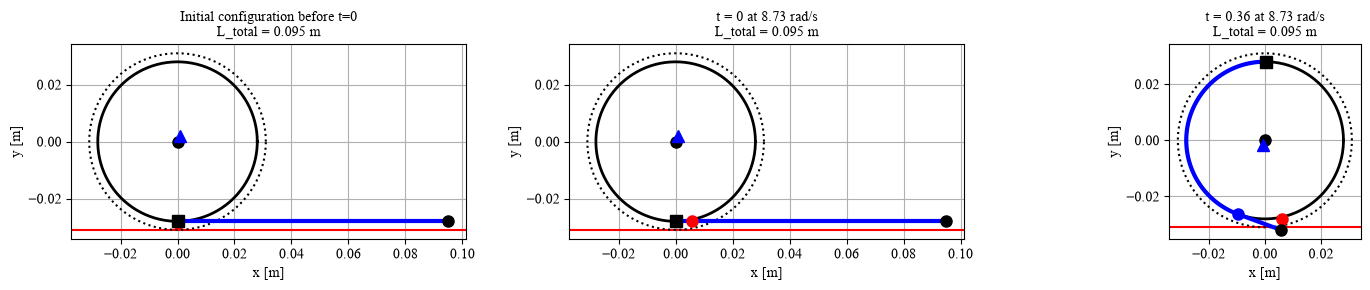

In [9]:
# Visualize at example windup speed
omega_wind_eg = 8.73
snapshots_eg = omega_to_contact_pt(omega_wind_eg)
p_tail_eg, phi_eg, p_CG_eg, p_anchor_eg, p_peel_eg, p_rod_offset_eg, t_eg = astuple(snapshots_eg[-1])

print(f"Tail end at contact: [{p_tail_eg[0,0]:.4f}, {p_tail_eg[1,0]:.4f}]")
print(f"Anchor rotation at contact: {phi_eg:.3f} rad")
print(f"Time to contact ground: {t_eg:.5f} s")

fig, axs = plt.subplots(1, 3, figsize = (15, 3))
plot_phase_1(snapshots_eg[0], "Initial configuration before t=0", fig, axs[0])
plot_phase_1(snapshots_eg[1], f"t = 0 at {omega_wind_eg} rad/s", fig, axs[1])
plot_phase_1(snapshots_eg[-1], f"t = {t_eg:.2f} at {omega_wind_eg} rad/s", fig, axs[2])
plt.tight_layout()
plt.show()

### Visualize interactive evolution for example windup speed

In [10]:
numsteps = len(snapshots_eg)
print(f"Number of steps: {numsteps}")

def show_frame(i):
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_phase_1(snapshots_eg[i], f"t = {snapshots_eg[i].t_sim:.5f} at {omega_wind_eg} rad/s", fig, ax)
    ax.set_xlim([-0.05, 0.125])
    ax.set_ylim([-0.04, 0.04])
    plt.tight_layout()
    plt.show()

interact(show_frame,
         i=IntSlider(min=0, max=numsteps-1, step=1, value=0,
                     description='step', continuous_update=True,
                     layout=Layout(width='800px')))


Number of steps: 3634


interactive(children=(IntSlider(value=0, description='step', layout=Layout(width='800px'), max=3633), Output()…

<function __main__.show_frame(i)>

### Simulate at every windup speed

In [11]:
omega_wind_exp_vals = df_summary['wind_omega_rad_s']
contact_snapshots = []
count = 0

for omega_wind_exp in omega_wind_exp_vals:
  contact_snapshot = omega_to_contact_pt(omega_wind_exp)[-1]
  contact_snapshots.append(contact_snapshot)
  count = count + 1
  print(f"Finished running {count}/{len(omega_wind_exp_vals)}")

Finished running 1/10
Finished running 2/10
Finished running 3/10
Finished running 4/10
Finished running 5/10
Finished running 6/10
Finished running 7/10
Finished running 8/10
Finished running 9/10
Finished running 10/10


### Phase 1 output plot: Model vs Results

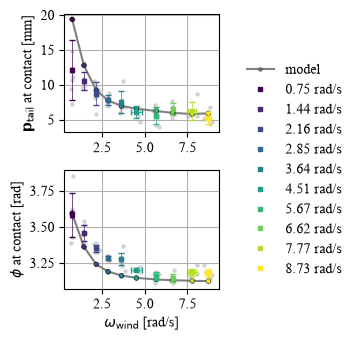

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))

# Phase 1 model
commanded_pct = df_summary.index
contact_x_vals = [cs.p_tail[0,0] for cs in contact_snapshots]
phi_vals = [cs.phi + 2*np.pi if cs.phi < 0 else cs.phi for cs in contact_snapshots]

# Sort by omega so connecting lines read left-to-right
order, exp_colors, model_colors = sort_by_omega(omega_wind_exp_vals)
omega_wind_exp_vals_sorted = np.array(omega_wind_exp_vals)[order]
contact_x_vals_sorted = np.array(contact_x_vals)[order]
phi_vals_sorted = np.array(phi_vals)[order]
pct_sorted = np.array(commanded_pct)[order]

# Plot predicted + experimental contact x distance per windup speed
plot_panel(axs[0], omega_wind_exp_vals_sorted, contact_x_vals_sorted, 'contact_x',
           r'$\mathbf{p}_\mathrm{tail}$ at contact [mm]',
           exp_colors, model_colors, scale=1000)

# Plot predicted + experimental orientation at contact per windup speed
plot_panel(axs[1], omega_wind_exp_vals_sorted, phi_vals_sorted, 'phi_contact',
           r'$\phi$ at contact [rad]',
           exp_colors, model_colors, wrap_ang=True)

axs[1].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# Single shared legend beside subplots
handles, labels = legend_handles_labels(exp_colors)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           ncol=1, fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('phase1_sysID.png', dpi=300, bbox_inches='tight')
plt.show()

### Phase 1 RMSE

In [13]:
RMSE_P1_contact_x = np.sqrt(np.mean((contact_x_vals_sorted-df_summary['contact_x'])**2))
RMSE_P1_phi = np.sqrt(np.mean((phi_vals_sorted-df_summary['phi_contact'])**2))

print(f"Phase 1 RMSE contact: {RMSE_P1_contact_x*1000:.1f} mm")
print(f"Phase 1 RMSE phi: {np.degrees(RMSE_P1_phi):.1f} degrees")

Phase 1 RMSE contact: 2.5 mm
Phase 1 RMSE phi: 4.2 degrees
